In [7]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
import sqlite3
import numpy as np 
import main as m

In [8]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet')
somatic_raw = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet')
germline = pd.concat([germline_raw, somatic_raw], ignore_index=True)
germline['Gene'] = germline['Gene'].astype(str).str.strip()

# for germline only:
# germline = germline_raw

sample_id = 'random_id'

In [9]:
splicing = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet')

In [10]:
conn = sqlite3.connect('human_genome.db')
query = "SELECT ensembl_gene_id, locus_group FROM genes"
types_df = pd.read_sql(query, conn)
types_df['geneID_short'] = types_df['ensembl_gene_id'].astype(str).str.split('.').str[0].str.strip()

In [11]:
# fix duplicate entries 
category_map = {
    'non-coding RNA': 'non-coding RNA/ pseudogene',
    'pseudogene': 'non-coding RNA/ pseudogene',
    'protein-coding gene': 'protein-coding gene',
    'other': 'other'
}
types_df['locus_group'] = types_df['locus_group'].map(category_map).fillna('other')
types_df = types_df.drop_duplicates(subset=['geneID_short'])
# before: 44960
# now: 42276

In [12]:
germline_mapped = m.map_symbols_to_gene_ids(germline, db_path)

In [13]:
merged = pd.merge(germline_mapped, types_df, on='geneID_short', how='left')
stats = (merged.groupby(['random_id', 'locus_group']).size().reset_index(name='cnv_count'))

/scratch/tmp/deben/ipykernel_1252181/1779676608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats, x='locus_group', y='cnv_count', order=order, palette='Set2', showfliers=False)


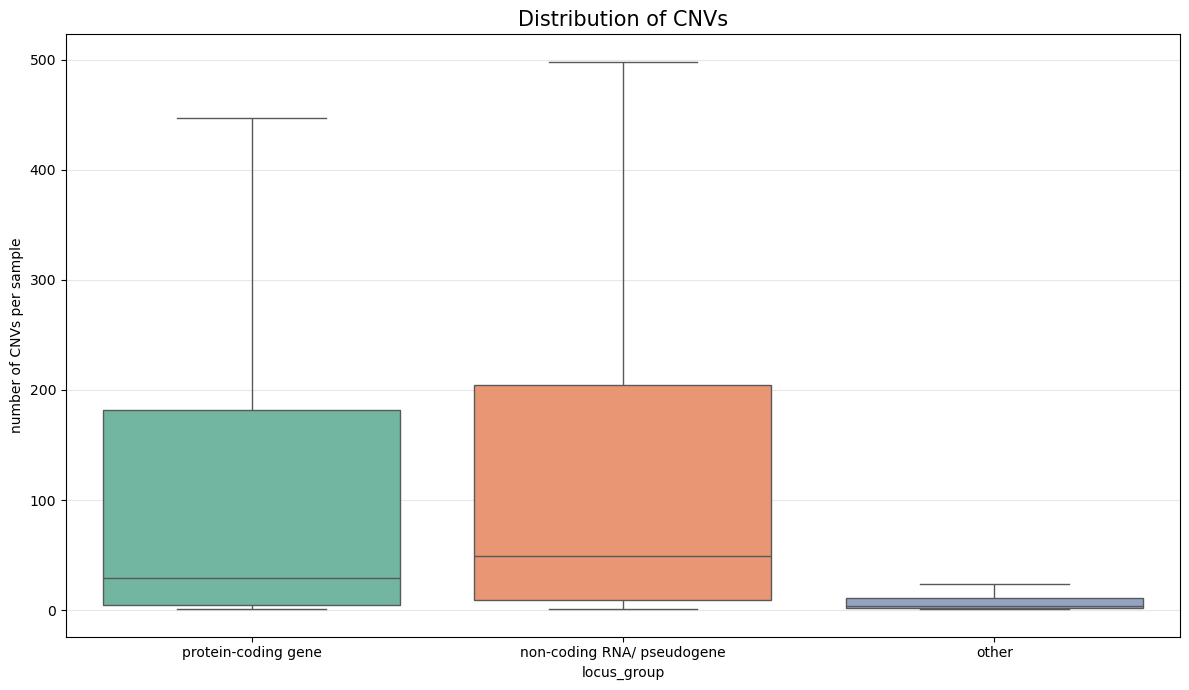

In [14]:
plt.figure(figsize=(12,7))
order = ['protein-coding gene', 'non-coding RNA/ pseudogene', 'other']
sns.boxplot(data=stats, x='locus_group', y='cnv_count', order=order, palette='Set2', showfliers=False)
plt.title('Distribution of CNVs', fontsize=15)
plt.ylabel('number of CNVs per sample')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cnv_by_type.png')
plt.show()

/scratch/tmp/deben/ipykernel_1252181/172920054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=merged_new, x='locus_group', order=order, palette='Set2')


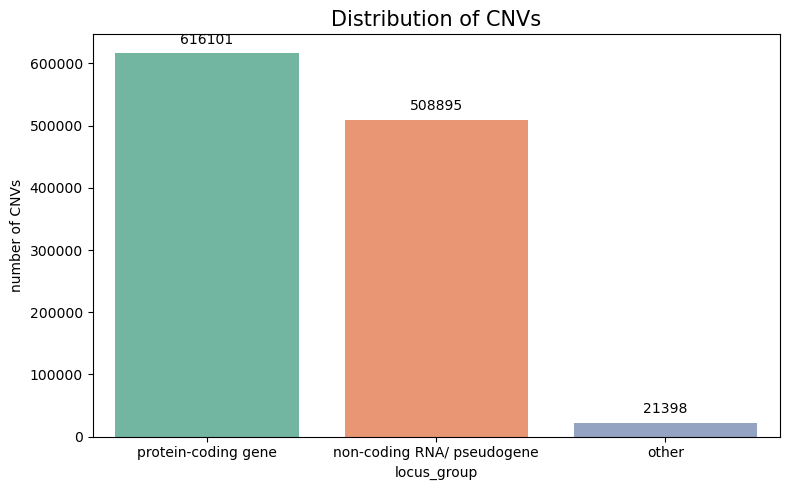

In [15]:
merged_new = pd.merge(germline_mapped, types_df, on='geneID_short', how='left')

plt.figure(figsize=(8,5))
ax = sns.countplot(data=merged_new, x='locus_group', order=order, palette='Set2')
plt.title('Distribution of CNVs', fontsize=15)
plt.ylabel('number of CNVs')

# show count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.savefig('cnv_by_type_general.png')
plt.show()

/scratch/tmp/deben/ipykernel_1252181/1686896796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=uq_genes, x='locus_group', order=order, palette='Set2')


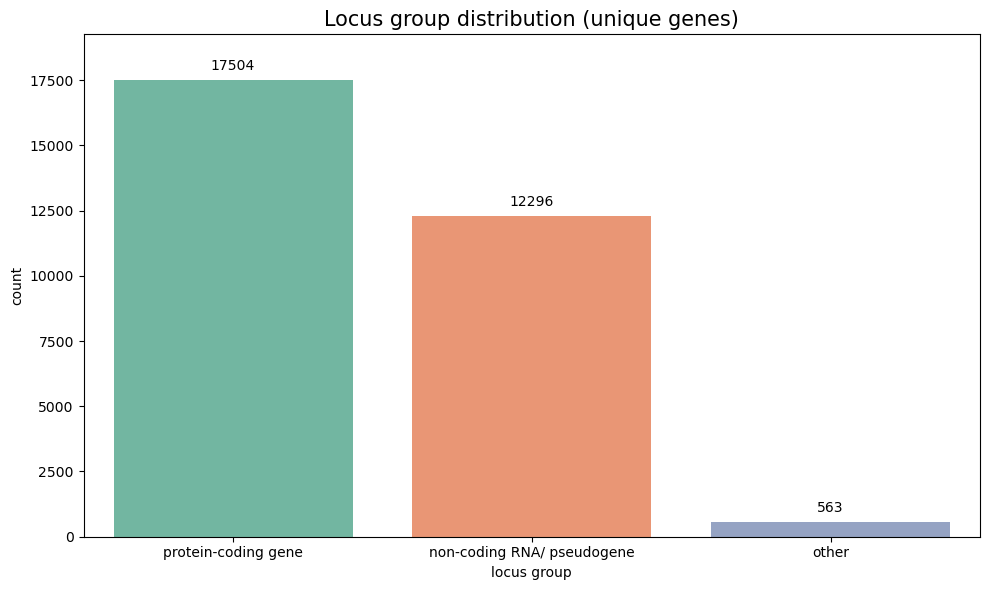

In [31]:
uq_genes = merged.drop_duplicates(subset=['Gene'])
order = ['protein-coding gene', 'non-coding RNA/ pseudogene', 'other']
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=uq_genes, x='locus_group', order=order, palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.title('Locus group distribution (unique genes)', fontsize=15)
plt.ylabel('count')
plt.xlabel('locus group')
plt.ylim(0, uq_genes['locus_group'].value_counts().max() * 1.1)
plt.tight_layout()
plt.savefig('locus_dist.png')
plt.show()

In [17]:
# just from fig. 2
cancers = ['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'DLBC', 'ESCA', 'GBM', 'HNSC', 'KICH', 'KIRC', 
            'KIRP', 'LAML', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'MESO', 'OV', 'PAAD', 'PCPG', 'PRAD', 'READ', 'SARC',
            'SKCM', 'STAD', 'TGCT', 'THCA', 'THYM', 'UCEC', 'UCS', 'UVM']
path_genes = [
    'BRCA1', 'BRCA2', 'ATM', 'PALB2', 'RET', 'NF1', 'MSH6', 'TP53',
    'VHL', 'BUB1B', 'SDHA', 'BAP1', 'SDHB', 'MAX', 'APC', 'FH',
    'WRN', 'SDHD', 'MET', 'HFE', 'PTEN'
]
# no samples in germline data for following genes: RET, MSH6, SDHB, MAX, APC, FH, WRN, HFE, PTEN

In [18]:
# created using AI, so need to check if its completely correct!!!
tcga_map = {
    # --- Breast (BRCA) ---
    'IDC': 'BRCA', 'ILC': 'BRCA', 'MDLC': 'BRCA', 'BRCA': 'BRCA', 'BREAST': 'BRCA',
    
    # --- Kidney (KICH, KIRC, KIRP) ---
    'CCRCC': 'KIRC', 'PRCC': 'KIRP', 'CHRB': 'KICH', 'KIRC': 'KIRC', 'KIRP': 'KIRP', 'KICH': 'KICH',
    
    # --- Sarcoma (SARC) ---
    'OS': 'SARC', 'LMS': 'SARC', 'ANGS': 'SARC', 'CHS': 'SARC', 'MPNST': 'SARC', 
    'SOFT_TISSUE': 'SARC', 'SCSARC': 'SARC', 'UPS': 'SARC', 'MFS': 'SARC', 'SARC': 'SARC',
    
    # --- Gastrointestinal (COAD, READ, STAD, PAAD, LIHC, CHOL, ESCA) ---
    'ADNOS': 'COAD', 'COAD': 'COAD', 'READ': 'READ', 'STAD': 'STAD', 'SDCA': 'STAD',
    'PAAD': 'PAAD', 'PANET': 'PAAD', 'LIHC': 'LIHC', 'LIVER': 'LIHC', 'CHOL': 'CHOL', 
    'ESCA': 'ESCA', 'EAC': 'ESCA', 'ESCC': 'ESCA',
    
    # --- Lung (LUAD, LUSC) ---
    'LUAD': 'LUAD', 'LUSC': 'LUSC', 'NSCLC': 'LUAD',
    
    # --- Brain (GBM, LGG) ---
    'GBM': 'GBM', 'LGG': 'LGG', 'AA': 'LGG', 'ODG': 'LGG', 'ASTR': 'LGG',
    
    # --- Other Direct/Common Mappings ---
    'THYM': 'THYM', 'UM': 'UVM', 'UVM': 'UVM', 'SKCM': 'SKCM', 'MEL': 'SKCM',
    'OV': 'OV', 'HNSC': 'HNSC', 'PRAD': 'PRAD', 'UCEC': 'UCEC', 'UCS': 'UCS',
    'BLCA': 'BLCA', 'ACC': 'ACC', 'CESC': 'CESC', 'DLBC': 'DLBC', 'MESO': 'MESO',
    'PCPG': 'PCPG', 'TGCT': 'TGCT', 'NSGCT': 'TGCT', 'SEM': 'TGCT', 'THCA': 'THCA',
    'THAP': 'THCA', 'LAML': 'LAML', 'AML': 'LAML'
}

In [19]:
total_n = germline_mapped[sample_id].nunique()
print(total_n)

hits = germline_mapped[germline_mapped['Gene'].isin(path_genes)]
counts = hits.groupby('Gene')[sample_id].nunique()
counts_pct = (counts / total_n) * 100
plot_df = counts_pct.reset_index(name='percent_carriers')


print(plot_df.sort_values('percent_carriers', ascending=False).head())

3547
     Gene  percent_carriers
15   SDHA          3.439526
13   PTEN          1.860727
18   TP53          1.832535
4   BRCA2          1.296871
6      FH          1.184099


/scratch/tmp/deben/ipykernel_1252181/1873380350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='percent_carriers', y='Gene', palette='Set2')


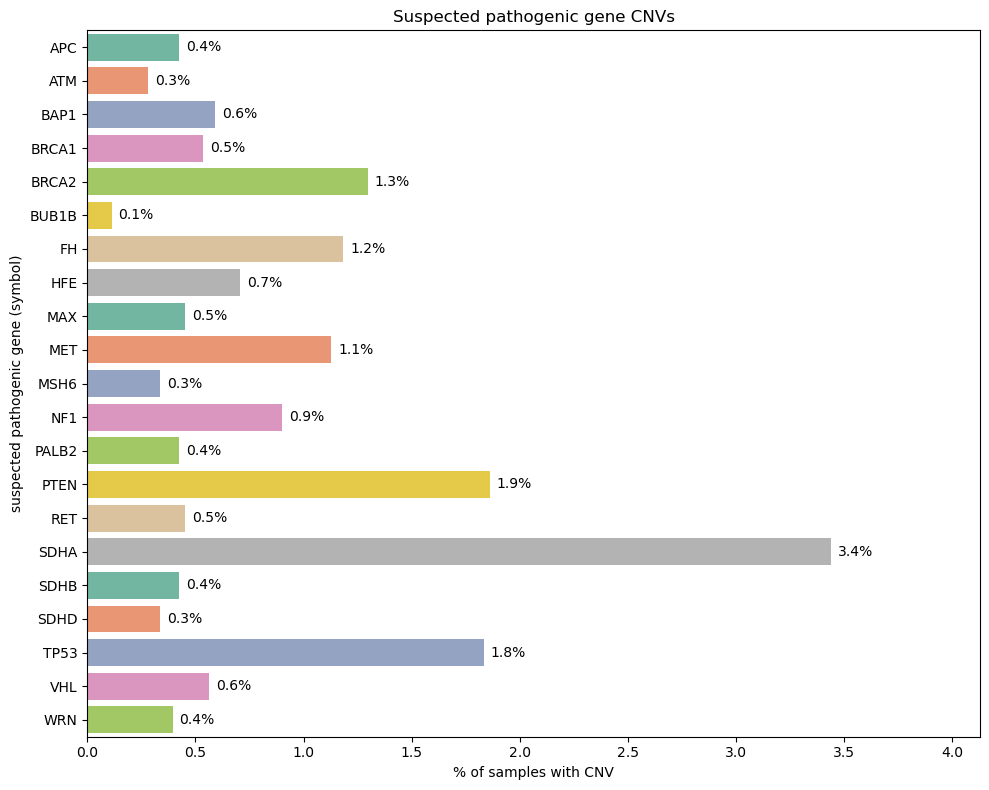

In [20]:
plt.figure(figsize=(10,8))
ax = sns.barplot(data=plot_df, x='percent_carriers', y='Gene', palette='Set2')
# add percent labels to bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%', 
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points')

plt.title('Suspected pathogenic gene CNVs')
plt.xlabel('% of samples with CNV')
plt.ylabel('suspected pathogenic gene (symbol)')
plt.xlim(0, max(plot_df['percent_carriers']) * 1.2)
plt.tight_layout()
plt.savefig('potentially_path_genes.png')
plt.show()

In [21]:
gene_map = {g.split(' [')[0]: g for g in path_genes}
clean_genes = list(gene_map.keys())

diag_map = splicing[['Oncotree Code', sample_id]].drop_duplicates()

germline_mapped['Gene'] = germline_mapped['Gene'].astype(str).str.strip()
germline_mapped = pd.merge(germline_mapped, diag_map, on=sample_id, how='left')
germline_mapped['TCGA_Code'] = germline_mapped['Oncotree Code'].map(tcga_map)
germline_mapped['TCGA_Code'] = germline_mapped['TCGA_Code'].fillna(germline_mapped['Oncotree Code'])

In [22]:
cohort_sizes = germline_mapped.drop_duplicates(sample_id).groupby('TCGA_Code').size()
hits = germline_mapped[germline_mapped['Gene'].isin(clean_genes)]
carrier_matrix = hits.groupby(['Gene', 'TCGA_Code'])[sample_id].nunique().unstack(fill_value=0)

relevant_sizes = cohort_sizes.reindex(carrier_matrix.columns)
carrier_pct_matrix = carrier_matrix.divide(cohort_sizes.reindex(carrier_matrix.columns), axis=1) * 100
carrier_pct_matrix.index = [gene_map.get(g, g) for g in carrier_pct_matrix.index]
final_heatmap_df = carrier_pct_matrix.reindex(index=path_genes, columns=cancers).fillna(0)

In [23]:
# for germline only
# germline_only_mapped = m.map_symbols_to_gene_ids(germline_raw, db_path)
# germline_only_mapped = pd.merge(germline_only_mapped, diag_map, on=sample_id, how='left')
# germline_only_mapped['TCGA_Code'] = germline_only_mapped['Oncotree Code'].map(tcga_map).fillna(germline_only_mapped['Oncotree Code'])

# hits_germline = germline_only_mapped[germline_only_mapped['Gene'].isin(clean_genes)]
# carrier_matrix_germline = hits_germline.groupby(['Gene', 'TCGA_Code'])[sample_id].nunique().unstack(fill_value=0)

# relevant_sizes = cohort_sizes.reindex(carrier_matrix_germline.columns)
# carrier_pct_matrix = carrier_matrix_germline.divide(cohort_sizes.reindex(carrier_matrix_germline.columns), axis=1) * 100
# carrier_pct_matrix.index = [gene_map.get(g, g) for g in carrier_pct_matrix.index]
# final_heatmap_df = carrier_pct_matrix.reindex(index=path_genes, columns=cancers).fillna(0)

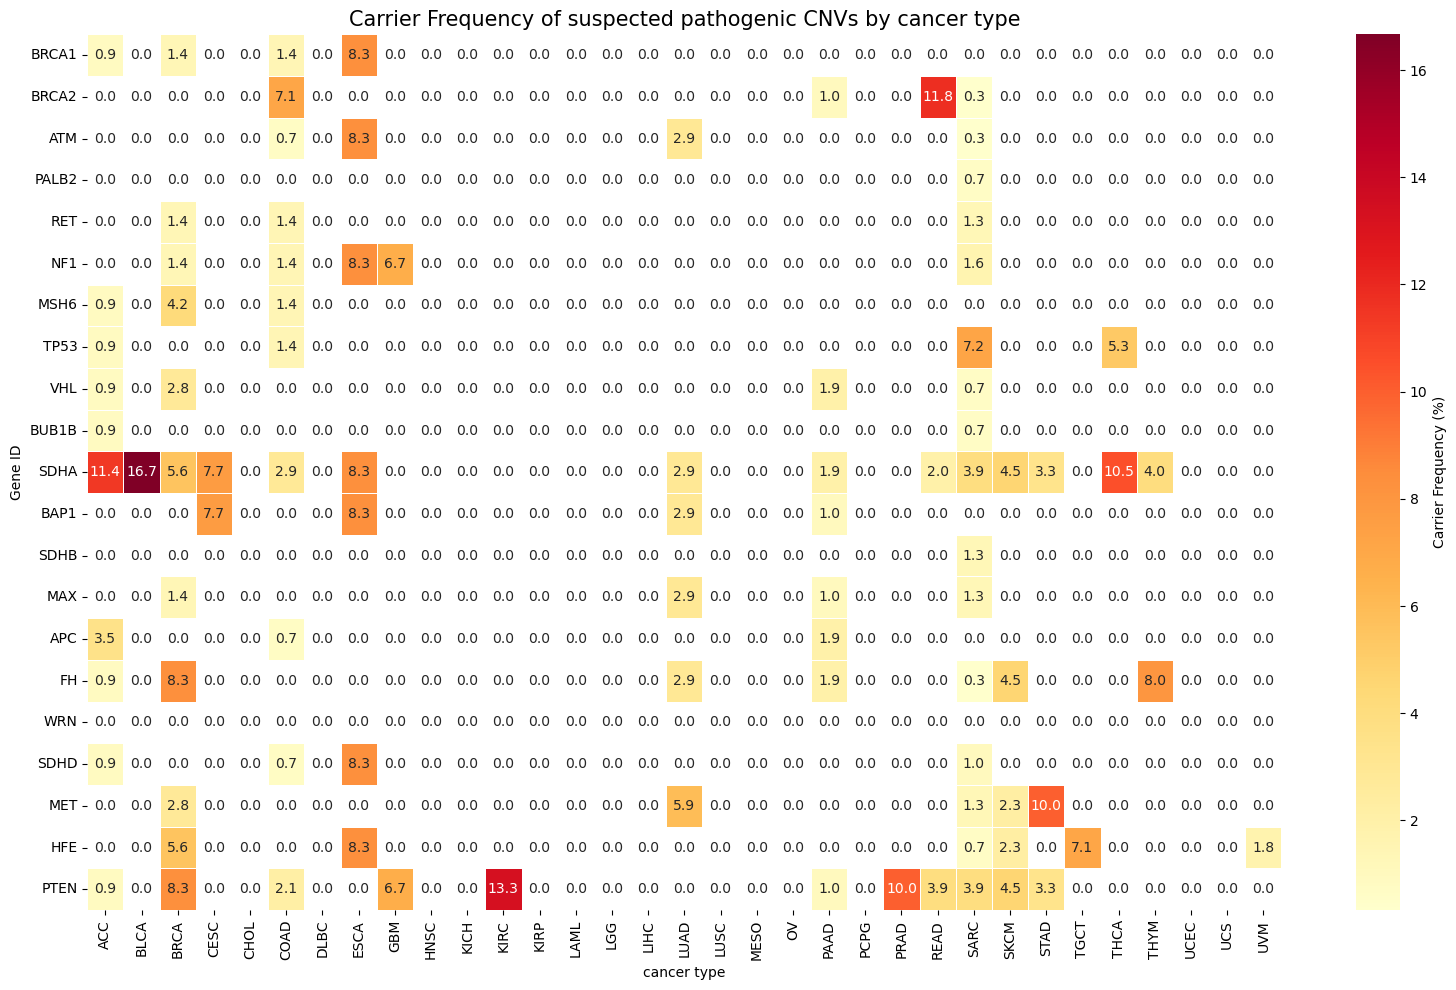

In [24]:
plt.figure(figsize=(16,10))
cmap = sns.color_palette('YlOrRd', as_cmap=True)
cmap.set_under('white')
mask_pos = final_heatmap_df > 0

ax = sns.heatmap(final_heatmap_df, 
                 annot=True,
                 fmt=".1f",  
                 cmap=cmap,
                 vmin= final_heatmap_df[mask_pos].min().min(),
                 linewidths=.5,
                 cbar_kws={'label': 'Carrier Frequency (%)'})

plt.title('Carrier Frequency of suspected pathogenic CNVs by cancer type', fontsize=15)
plt.xlabel('cancer type')
plt.ylabel('Gene ID')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

In [25]:
# look at pseudogenes and ncRNA specifically, since they seem to have the most hits 
pn_cnvs = merged[merged['locus_group'].isin(['non-coding RNA/ pseudogene'])].copy()
print(len(pn_cnvs))

508895


In [26]:
top_noisy_genes = (pn_cnvs.groupby(['Gene', 'locus_group'])
                   .size()
                   .sort_values(ascending=False)
                   .head(20)
                   .reset_index(name='hit_count'))

print(top_noisy_genes[['Gene', 'hit_count']])

         Gene  hit_count
0     TSPY22P        550
1     TTTY25P        550
2       TTTY5        550
3     RBMY2FP        550
4      TTTY14        549
5     MTCYBP2        549
6   RNU6-255P        549
7     OFD1P7Y        548
8     TBL1YP1        548
9    ZNF839P1        548
10     CDY10P        547
11     CD24P4        547
12   GAPDHP19        547
13     BCORP1        547
14  TRAPPC2P7        546
15    OFD1P6Y        546
16     TTTY13        546
17    USP9YP2        546
18   USP9YP28        546
19   USP9YP10        546


In [27]:
pn_genes = top_noisy_genes['Gene']
top_hits_data = merged_new[merged_new['Gene'].isin(pn_genes)]
sample_distribution = top_hits_data.groupby(['Gene', sample_id]).size().reset_index(name='hit_count')
for gene in pn_genes:
    gene_data = sample_distribution[sample_distribution['Gene'] == gene]
    unique_samples = gene_data[sample_id].nunique()
    max_hits_single_sample = gene_data['hit_count'].max()
    avg_hits = gene_data['hit_count'].mean()
    

    print(f"Total Hits: {top_hits_data[top_hits_data['Gene'] == gene].shape[0]}")
    print(f"Unique Samples carrying a hit: {unique_samples}")
    print(f"avg hits per carrier: {avg_hits:.2f}")
    print(f"max hits in a single sample: {max_hits_single_sample}")
    print('\n\n')

Total Hits: 550
Unique Samples carrying a hit: 548
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 550
Unique Samples carrying a hit: 548
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 550
Unique Samples carrying a hit: 548
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 550
Unique Samples carrying a hit: 548
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 549
Unique Samples carrying a hit: 547
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 549
Unique Samples carrying a hit: 547
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 549
Unique Samples carrying a hit: 547
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 548
Unique Samples carrying a hit: 546
avg hits per carrier: 1.00
max hits in a single sample: 2



Total Hits: 548
Unique Samples carrying a hit: 545
avg hits per carrier: 1.01
max hits in a single sampl

In [28]:
high_copy_pn = pn_cnvs[pn_cnvs['TCN'] >= 8].copy()
print(len(high_copy_pn))

184844


In [29]:
top_intensity_genes = (high_copy_pn.groupby('Gene')['TCN']
                       .agg(['mean', 'max', 'count'])
                       .sort_values(by='mean', ascending=False)
                       .head(20))

print("top 20 non coding genes:")
print(top_intensity_genes)

top 20 non coding genes:
                  mean         max  count
Gene                                     
RN7SKP167   128.705762  673.216239     11
RPS15AP5    126.449028  673.216239     14
MIR4728      78.578618  279.992821     53
RN7SL104P    74.307214  272.681208     15
RNU6-233P    66.546448  310.202749     39
RNU5E-7P     64.343419  272.681208     14
RNA5SP174    61.416461   61.416461      1
RNA5SP175    61.416461   61.416461      1
RNU6-1055P   54.954719  100.199358      2
RNU6-952P    52.260325  301.784484     24
UQCRHP4      51.862065  292.743795      8
KRT8P34      51.567943  264.486554     37
RPS15AP3     48.466295  278.862033      7
MIR3920      45.536611  194.278134     17
MIR4714      44.348221  343.628442     25
RBM43P1      43.676696  255.407476      8
RNU7-4P      43.521003  216.118920    123
RN7SL737P    43.466125  120.078865     11
PRELID2P1    43.309352  248.922425    122
RN7SL441P    42.847749  118.404879      7


In [30]:
# top_sample_hits = high_copy_pn[[sample_id, 'Gene', 'TCN']].sort_values(by='TCN', ascending=False).head(20)
# print(top_sample_hits)